In [4]:
# Cell 1: تثبيت المكتبات الضرورية
!pip install mediapipe opencv-python pandas scikit-learn seaborn matplotlib tqdm
!pip install torch torchvision torchaudio

In [5]:
# Cell 2: استيراد المكتبات
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# التحقق من وجود GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Cell 3: تحميل البيانات وتجهيزها
# تحديد مسارات البيانات
DATASET_DIR = '/content/drive/MyDrive/project/DATA_DEEP_FAKE/Celeb-DF-v2'
OUTPUT_FACE_DIR = '/content/drive/MyDrive/CelebDF_faces'
CSV_OUTPUT_PATH = '/content/drive/MyDrive/Gobal_metadata.csv'

# تحميل البيانات الوصفية
df = pd.read_csv(CSV_OUTPUT_PATH)
print(f"Total samples: {len(df)}")
print(df['label'].value_counts())

# جمع مسارات الفيديوهات
video_paths = []
labels = []

for idx, row in df.iterrows():
    video_file = row['file']
    label = row['label']

    # البحث عن الملف في المجلدات المختلفة
    possible_paths = [
        f"/content/drive/MyDrive/Celeb_face_only/Celeb-real/{video_file}",
        f"/content/drive/MyDrive/Celeb_face_only/YouTube-real/{video_file}",
        f"/content/drive/MyDrive/Celeb_face_only/Celeb-synthesis/{video_file}",
        f"/content/drive/MyDrive/CelebDF_faces/{video_file}"
    ]

    for path in possible_paths:
        if os.path.exists(path):
            video_paths.append(path)
            labels.append(0 if label == 'FAKE' else 1)  # FAKE=0, REAL=1
            break

print(f"Found {len(video_paths)} videos")
print(f"REAL: {sum(labels)}, FAKE: {len(labels) - sum(labels)}")

Total samples: 6536
label
FAKE    5647
REAL     889
Name: count, dtype: int64
Found 6536 videos
REAL: 889, FAKE: 5647


In [8]:
# Cell 4: Handling Data Imbalance with Advanced Augmentation

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import cv2
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
import random
import os

print("🔄 Advanced Data Augmentation for REAL Videos...")

# تعريف real_paths و fake_paths من البيانات المتاحة
real_paths = [path for path, label in zip(video_paths, labels) if label == 1]
fake_paths = [path for path, label in zip(video_paths, labels) if label == 0]

# إحصائيات البيانات قبل المعالجة
real_count = len(real_paths)
fake_count = len(fake_paths)
required_augmentations = fake_count - real_count

print(f"📊 البيانات الأصلية: REAL: {real_count}, FAKE: {fake_count}")
print(f"🎯 المطلوب توليد {required_augmentations} عينة REAL جديدة")

class VideoAugmenter:
    def __init__(self):
        # تحويلات مكانية (Spatial Transformations)
        self.spatial_transforms = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.Rotate(limit=15, p=0.4),
            A.ShiftScaleRotate(
                shift_limit=0.1,
                scale_limit=0.1,
                rotate_limit=10,
                p=0.4
            ),
            A.Perspective(scale=(0.05, 0.1), p=0.3),
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2),
        ])

        # تحويلات لونية وإضاءة (Color & Lighting Transformations)
        self.color_transforms = A.Compose([
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.5),
            A.RandomGamma(gamma_limit=(80, 120), p=0.3),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
        ])

        # تحويلات الضوضاء والجودة (Noise & Quality Transformations)
        self.noise_transforms = A.Compose([
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),
            A.MotionBlur(blur_limit=7, p=0.3),
            A.MedianBlur(blur_limit=3, p=0.2),
            A.GaussianBlur(blur_limit=3, p=0.3),
            A.ImageCompression(quality_lower=70, quality_upper=90, p=0.3),
        ])

    def augment_frame(self, frame):
        """تطبيق التحويلات على إطار واحد"""
        try:
            # تطبيق التحويلات المكانية
            augmented = self.spatial_transforms(image=frame)
            frame = augmented['image']

            # تطبيق التحويلات اللونية
            augmented = self.color_transforms(image=frame)
            frame = augmented['image']

            # تطبيق تحويلات الضوضاء
            augmented = self.noise_transforms(image=frame)
            frame = augmented['image']

            return frame
        except Exception as e:
            print(f"⚠️ خطأ في augment_frame: {e}")
            return frame

    def augment_video(self, video_path, output_path, num_frames_to_augment=10):
        """توليد فيديو معزز من فيديو أصلي"""
        try:
            cap = cv2.VideoCapture(video_path)
            if not cap.isOpened():
                print(f"❌ لا يمكن فتح الفيديو: {video_path}")
                return False

            frames = []

            # استخراج الإطارات من الفيديو
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame)

            cap.release()

            if len(frames) == 0:
                print(f"❌ لا توجد إطارات في الفيديو: {video_path}")
                return False

            # اختيار إطارات عشوائية للتعديل (لتحسين الكفاءة)
            if len(frames) > num_frames_to_augment:
                selected_indices = random.sample(range(len(frames)), num_frames_to_augment)
            else:
                selected_indices = range(len(frames))

            # تطبيق التحويلات على الإطارات المختارة
            augmented_frames = []
            for idx in range(len(frames)):
                if idx in selected_indices:
                    augmented_frame = self.augment_frame(frames[idx])
                    augmented_frames.append(augmented_frame)
                else:
                    augmented_frames.append(frames[idx])

            # حفظ الفيديو المعزز
            return self.save_video(augmented_frames, output_path)

        except Exception as e:
            print(f"❌ خطأ في augment_video: {e}")
            return False

    def save_video(self, frames, output_path, fps=30):
        """حفظ الإطارات كفيديو"""
        try:
            if len(frames) == 0:
                return False

            height, width = frames[0].shape[:2]
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

            for frame in frames:
                frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
                out.write(frame_bgr)

            out.release()
            return True
        except Exception as e:
            print(f"❌ خطأ في حفظ الفيديو: {e}")
            return False

def generate_synthetic_real_data(real_paths, num_to_generate):
    """توليد بيانات REAL اصطناعية"""
    augmenter = VideoAugmenter()
    generated_paths = []

    # إنشاء مجلد للحفظ
    os.makedirs('augmented_real', exist_ok=True)

    # إذا كان العدد المطلوب كبير جداً، نحدده ليكون 2000 كحد أقصى
    num_to_generate = min(num_to_generate, 4000)
    print(f"🔄 سيتم توليد {num_to_generate} فيديو (محدد للكفاءة)")

    # توليد العدد المطلوب
    successful_generations = 0
    max_attempts = num_to_generate * 2  # حد أقصى للمحاولات

    for attempt in range(max_attempts):
        if successful_generations >= num_to_generate:
            break

        # اختيار فيديو عشوائي من REAL كمصدر
        source_video = random.choice(real_paths)

        # إنشاء مسار للفيديو المُنْتَج
        base_name = os.path.basename(source_video).split('.')[0]
        output_filename = f"augmented_real/aug_real_{successful_generations}_{base_name}.mp4"

        # تجنب التكرار
        if os.path.exists(output_filename):
            continue

        # تطبيق التحويلات المتقدمة
        success = augmenter.augment_video(source_video, output_filename)

        if success:
            generated_paths.append(output_filename)
            successful_generations += 1

            if successful_generations % 50 == 0:
                print(f"✅ تم توليد {successful_generations} فيديو من أصل {num_to_generate}")

    print(f"🎉 تم توليد {successful_generations} فيديو بنجاح")
    return generated_paths

# التطبيق الرئيسي
if required_augmentations > 0 and len(real_paths) > 0:
    print("🚀 بدء توليد فيديوهات REAL اصطناعية...")

    # توليد البيانات الجديدة
    augmented_real_paths = generate_synthetic_real_data(real_paths, required_augmentations)

    if len(augmented_real_paths) > 0:
        # تحديث البيانات
        video_paths = video_paths + augmented_real_paths
        labels = labels + [1] * len(augmented_real_paths)

        print(f"✅ تم إضافة {len(augmented_real_paths)} عينة REAL جديدة")
    else:
        print("⚠️ لم يتم توليد أي فيديوهات جديدة")
else:
    print("✅ البيانات متوازنة بالفعل أو لا توجد عينات REAL")

# إحصائيات بعد المعالجة
print(f"\n📊 البيانات بعد المعالجة:")
print(f"REAL: {sum(labels)}, FAKE: {len(labels) - sum(labels)}")
print(f"إجمالي العينات: {len(video_paths)}")

# حساب الأوزان من البيانات المحدثة
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"\n🎯 الأوزان الجديدة: {class_weights}")
print(f"🔍 نسبة FAKE:REAL = {(len(labels) - sum(labels)) / sum(labels):.2f}:1")

🔄 Advanced Data Augmentation for REAL Videos...
📊 البيانات الأصلية: REAL: 889, FAKE: 5647
🎯 المطلوب توليد 4758 عينة REAL جديدة
🚀 بدء توليد فيديوهات REAL اصطناعية...
🔄 سيتم توليد 4000 فيديو (محدد للكفاءة)
✅ تم توليد 50 فيديو من أصل 4000
✅ تم توليد 100 فيديو من أصل 4000
✅ تم توليد 150 فيديو من أصل 4000
✅ تم توليد 200 فيديو من أصل 4000
✅ تم توليد 250 فيديو من أصل 4000
✅ تم توليد 300 فيديو من أصل 4000
✅ تم توليد 350 فيديو من أصل 4000
✅ تم توليد 400 فيديو من أصل 4000
✅ تم توليد 450 فيديو من أصل 4000
✅ تم توليد 500 فيديو من أصل 4000
✅ تم توليد 550 فيديو من أصل 4000
✅ تم توليد 600 فيديو من أصل 4000
✅ تم توليد 650 فيديو من أصل 4000
✅ تم توليد 700 فيديو من أصل 4000
✅ تم توليد 750 فيديو من أصل 4000
✅ تم توليد 800 فيديو من أصل 4000
✅ تم توليد 850 فيديو من أصل 4000
✅ تم توليد 900 فيديو من أصل 4000
✅ تم توليد 950 فيديو من أصل 4000
✅ تم توليد 1000 فيديو من أصل 4000
✅ تم توليد 1050 فيديو من أصل 4000
✅ تم توليد 1100 فيديو من أصل 4000
✅ تم توليد 1150 فيديو من أصل 4000
✅ تم توليد 1200 فيديو من أصل 4000


In [9]:
# Cell 4: فئة Dataset المخصصة (محسنة)
class DeepFakeDataset(Dataset):
    def __init__(self, video_paths, labels, sequence_length=10, transform=None, frame_size=(112, 112)):
        self.video_paths = video_paths
        self.labels = labels
        self.sequence_length = sequence_length
        self.transform = transform
        self.frame_size = frame_size

        # تحقق من صحة البيانات
        self.valid_indices = self._validate_video_paths()
        print(f"✅ عدد الفيديوهات الصالحة: {len(self.valid_indices)}/{len(video_paths)}")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        actual_idx = self.valid_indices[idx]
        video_path = self.video_paths[actual_idx]
        label = self.labels[actual_idx]

        try:
            # استخراج الإطارات من الفيديو
            frames = self.extract_frames(video_path, self.sequence_length)

            if frames is None or len(frames) == 0:
                return self._get_dummy_data(label)

            if self.transform:
                frames = [self.transform(frame) for frame in frames]

            frames = torch.stack(frames)
            return frames, torch.tensor(label, dtype=torch.long)

        except Exception as e:
            print(f"❌ Error loading {video_path}: {e}")
            return self._get_dummy_data(label)

    def extract_frames(self, video_path, num_frames):
        """استخراج الإطارات مع معالجة أفضل للأخطاء"""
        # تحقق من وجود الملف
        if not os.path.exists(video_path):
            print(f"⚠️ الملف غير موجود: {video_path}")
            return None

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"⚠️ لا يمكن فتح الفيديو: {video_path}")
            return None

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # إذا كان الفيديو فارغاً
        if total_frames == 0:
            cap.release()
            return None

        # اختيار إطارات عشوائية بشكل أكثر ذكاءً
        if total_frames >= num_frames:
            # اختيار إطارات موزعة بشكل متساوٍ
            indices = np.linspace(0, total_frames-1, num_frames, dtype=int)
        else:
            # إذا كانت الإطارات أقل من المطلوب، نكرر بعضها
            indices = list(range(total_frames))
            # إضافة إطارات عشوائية إضافية
            while len(indices) < num_frames:
                indices.append(np.random.randint(0, total_frames))
            indices = indices[:num_frames]

        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, self.frame_size)
                frames.append(frame)
            else:
                # إضافة إطار أسود في حالة الفشل
                black_frame = np.zeros((self.frame_size[1], self.frame_size[0], 3), dtype=np.uint8)
                frames.append(black_frame)

        cap.release()

        # تحقق من أن عدد الإطارات صحيح
        if len(frames) != num_frames:
            print(f"⚠️ عدد الإطارات غير متطابق في {video_path}: {len(frames)} != {num_frames}")
            # تعويض النقص بإطارات سوداء
            while len(frames) < num_frames:
                black_frame = np.zeros((self.frame_size[1], self.frame_size[0], 3), dtype=np.uint8)
                frames.append(black_frame)

        return frames[:num_frames]

    def _get_dummy_data(self, label):
        """إرجاع بيانات بديلة في حالة الخطأ"""
        dummy_frames = torch.zeros(self.sequence_length, 3, self.frame_size[1], self.frame_size[0])
        return dummy_frames, torch.tensor(label, dtype=torch.long)

    def _validate_video_paths(self):
        """التحقق من صحة مسارات الفيديو"""
        valid_indices = []
        for idx, path in enumerate(self.video_paths):
            if os.path.exists(path):
                valid_indices.append(idx)
            else:
                print(f"⚠️ مسار غير موجود: {path}")

        return valid_indices

    def get_class_distribution(self):
        """الحصول على توزيع الفئات"""
        valid_labels = [self.labels[i] for i in self.valid_indices]
        real_count = sum(valid_labels)
        fake_count = len(valid_labels) - real_count
        return real_count, fake_count

In [10]:
# Cell 5: تحويلات البيانات وإنشاء الداتالودر
from torchvision import transforms

# تحويلات البيانات
data_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# إنشاء الداتاست
print("📦 إنشاء مجموعة البيانات...")
dataset = DeepFakeDataset(
    video_paths=video_paths,
    labels=labels,
    sequence_length=10,
    transform=data_transform,
    frame_size=(112, 112)
)

# عرض إحصائيات البيانات
real_count, fake_count = dataset.get_class_distribution()
print(f"🎯 توزيع الفئات في الداتاست:")
print(f"   REAL: {real_count} ({real_count/len(dataset)*100:.1f}%)")
print(f"   FAKE: {fake_count} ({fake_count/len(dataset)*100:.1f}%)")
print(f"   الإجمالي: {len(dataset)} فيديو")

# اختبار عينة من البيانات
if len(dataset) > 0:
    sample_frames, sample_label = dataset[0]
    print(f"📊 شكل العينة: {sample_frames.shape}")
    print(f"🏷️  تسمية العينة: {'REAL' if sample_label == 1 else 'FAKE'}")

📦 إنشاء مجموعة البيانات...
✅ عدد الفيديوهات الصالحة: 10536/10536
🎯 توزيع الفئات في الداتاست:
   REAL: 4889 (46.4%)
   FAKE: 5647 (53.6%)
   الإجمالي: 10536 فيديو
📊 شكل العينة: torch.Size([10, 3, 112, 112])
🏷️  تسمية العينة: REAL


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DeepFakeDetector(nn.Module):
    def __init__(self, num_classes=2, latent_dim=512, hidden_dim=256, num_layers=2, dropout=0.1, bidirectional=True):
        super(DeepFakeDetector, self).__init__()

        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        # CNN backbone
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4))
        )

        # Linear projection for LSTM
        self.feature_projection = nn.Linear(256 * 4 * 4, latent_dim)

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=latent_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        # Calculate classifier input dimension
        classifier_input_dim = hidden_dim * 2 if bidirectional else hidden_dim

        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(classifier_input_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        batch_size, seq_length, c, h, w = x.shape

        # Process each frame with CNN
        x = x.view(batch_size * seq_length, c, h, w)
        cnn_features = self.cnn(x)
        cnn_features = cnn_features.view(batch_size * seq_length, -1)

        # Project to LSTM dimension
        projected_features = self.feature_projection(cnn_features)
        projected_features = projected_features.view(batch_size, seq_length, -1)

        # Process sequence with LSTM
        lstm_out, (hidden, cell) = self.lstm(projected_features)

        # Use the last hidden state for classification
        if self.bidirectional:
            # For bidirectional LSTM, concatenate the last forward and backward hidden states
            hidden_forward = hidden[-2, :, :]  # Second to last layer - forward
            hidden_backward = hidden[-1, :, :]  # Last layer - backward
            cls_features = torch.cat((hidden_forward, hidden_backward), dim=1)
        else:
            # For unidirectional LSTM, use the last hidden state
            cls_features = hidden[-1, :, :]

        output = self.classifier(cls_features)
        return output

    def init_hidden(self, batch_size, device):
        """Initialize hidden state for LSTM"""
        num_directions = 2 if self.bidirectional else 1
        hidden = torch.zeros(self.num_layers * num_directions, batch_size, self.hidden_dim).to(device)
        cell = torch.zeros(self.num_layers * num_directions, batch_size, self.hidden_dim).to(device)
        return hidden, cell

In [12]:
# Cell 6: تقسيم البيانات وإعداد DataLoader (مع تحسينات)

# تحويلات الصور
im_size = 112
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((im_size, im_size)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # إضافة لتحسين التعميم
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((im_size, im_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# تقسيم البيانات
print("📊 تقسيم البيانات...")
train_paths, test_paths, train_labels, test_labels = train_test_split(
    video_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels, test_size=0.2, random_state=42, stratify=train_labels
)

# عرض التوزيع المفصل
def print_distribution(name, paths, labels):
    real_count = sum(labels)
    fake_count = len(labels) - real_count
    total = len(labels)
    print(f"{name}:")
    print(f"  REAL: {real_count} ({real_count/total*100:.1f}%)")
    print(f"  FAKE: {fake_count} ({fake_count/total*100:.1f}%)")
    print(f"  Total: {total}")

print_distribution("🎯 Training", train_paths, train_labels)
print_distribution("📊 Validation", val_paths, val_labels)
print_distribution("🧪 Test", test_paths, test_labels)

# إنشاء DataLoaders
print("\n📦 إنشاء DataLoaders...")
train_dataset = DeepFakeDataset(train_paths, train_labels, sequence_length=10, transform=train_transforms)
val_dataset = DeepFakeDataset(val_paths, val_labels, sequence_length=10, transform=test_transforms)
test_dataset = DeepFakeDataset(test_paths, test_labels, sequence_length=10, transform=test_transforms)

# عرض إحصائيات الداتاست بعد التصفية
print("\n✅ الداتاست النهائية بعد تصفية الملفات التالفة:")
print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset: {len(val_dataset)} samples")
print(f"Test dataset: {len(test_dataset)} samples")

# حساب class weights للتدريب (اختياري)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels_np = [train_labels[i] for i in train_dataset.valid_indices]
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels_np),
    y=train_labels_np
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"🎯 Class weights: {class_weights}")

# إنشاء DataLoaders مع إعدادات محسنة
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True if device == 'cuda' else False  # تحسين الأداء للـ GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True if device == 'cuda' else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True if device == 'cuda' else False
)

# اختبار تحميل دفعة من البيانات
print("\n🧪 اختبار تحميل البيانات...")
if len(train_loader) > 0:
    for batch_idx, (frames, labels_batch) in enumerate(train_loader):
        print(f"📊 شكل الدفعة: {frames.shape}")
        print(f"🏷️ توزيع التسميات في الدفعة: REAL: {sum(labels_batch).item()}, FAKE: {len(labels_batch) - sum(labels_batch).item()}")
        break

📊 تقسيم البيانات...
🎯 Training:
  REAL: 3129 (46.4%)
  FAKE: 3613 (53.6%)
  Total: 6742
📊 Validation:
  REAL: 782 (46.4%)
  FAKE: 904 (53.6%)
  Total: 1686
🧪 Test:
  REAL: 978 (46.4%)
  FAKE: 1130 (53.6%)
  Total: 2108

📦 إنشاء DataLoaders...
✅ عدد الفيديوهات الصالحة: 6742/6742
✅ عدد الفيديوهات الصالحة: 1686/1686
✅ عدد الفيديوهات الصالحة: 2108/2108

✅ الداتاست النهائية بعد تصفية الملفات التالفة:
Train dataset: 6742 samples
Val dataset: 1686 samples
Test dataset: 2108 samples
🎯 Class weights: tensor([0.9330, 1.0773], device='cuda:0')

🧪 اختبار تحميل البيانات...
📊 شكل الدفعة: torch.Size([8, 10, 3, 112, 112])
🏷️ توزيع التسميات في الدفعة: REAL: 3, FAKE: 5


In [13]:
# Cell 7: دوال التدريب والتقييم
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc="Training")
    for batch_idx, (frames, labels) in enumerate(pbar):
        frames, labels = frames.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(frames)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for frames, labels in tqdm(dataloader, desc="Evaluating"):
            frames, labels = frames.to(device), labels.to(device)

            outputs = model(frames)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

In [14]:
# Cell 7: تعريف النموذج والتدريب المتقدم

import torch
import torch.nn as nn
import torchvision.models as models

# =========================
# تعريف نموذج DeepFake Detector
# =========================

class DeepFakeDetector(nn.Module):
    def __init__(self, num_classes=2, sequence_length=10, backbone='resnet18'):
        super(DeepFakeDetector, self).__init__()
        self.sequence_length = sequence_length

        # استخدام backbone pre-trained
        if backbone == 'resnet18':
            self.backbone = models.resnet18(pretrained=True)
            # إزالة ال fully connected الأخير
            self.feature_dim = self.backbone.fc.in_features
            self.backbone = nn.Sequential(*list(self.backbone.children())[:-1])
        elif backbone == 'efficientnet':
            self.backbone = models.efficientnet_b0(pretrained=True)
            self.feature_dim = self.backbone.classifier[1].in_features
            self.backbone = nn.Sequential(*list(self.backbone.children())[:-1])
        else:
            raise ValueError(f"Backbone {backbone} not supported")

        # تجميد أوزان ال backbone في البداية (اختياري)
        for param in self.backbone.parameters():
            param.requires_grad = False

        # طبقات لمعالجة التسلسل الزمني
        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=512,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512 * 2, 256),  # *2 لأن bidirectional
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

        # Adaptive pooling للتعامل مع أحجام مختلفة
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        # x shape: [batch_size, sequence_length, channels, height, width]
        batch_size, seq_len = x.size(0), x.size(1)

        # دمج البعدين batch و sequence للمعالجة
        x = x.view(batch_size * seq_len, x.size(2), x.size(3), x.size(4))

        # استخراج المميزات من كل إطار
        features = self.backbone(x)
        features = self.adaptive_pool(features)
        features = features.view(features.size(0), -1)

        # إعادة تشكيل للبعد الزمني
        features = features.view(batch_size, seq_len, -1)

        # معالجة التسلسل الزمني
        lstm_out, (hidden, cell) = self.lstm(features)

        # استخدام آخر hidden state للتصنيف
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # bidirectional
        output = self.classifier(hidden)

        return output

    def unfreeze_backbone(self, unfreeze=True):
        """فك تجميد أوزان ال backbone لتدريبها"""
        for param in self.backbone.parameters():
            param.requires_grad = unfreeze

# =========================
# تهيئة النموذج والتأكد من وجوده على الجهاز الصحيح
# =========================
print("🔄 تهيئة النموذج...")
model = DeepFakeDetector(
    num_classes=2,
    sequence_length=10,
    backbone='resnet18'
)

# نقل النموذج إلى الجهاز المناسب أولاً
model = model.to(device)

# عرض بنية النموذج
print(f"🎯 النموذج المُنشأ:")
print(f"عدد المعاملات: {sum(p.numel() for p in model.parameters()):,}")
print(f"عدد المعاملات القابلة للتدريب: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"📍 النموذج على جهاز: {next(model.parameters()).device}")

# اختبار تمرير عينة عبر النموذج
if len(train_dataset) > 0:
    sample_frames, sample_label = train_dataset[0]
    sample_frames = sample_frames.unsqueeze(0)  # إضافة batch dimension

    # نقل البيانات إلى نفس جهاز النموذج
    sample_frames = sample_frames.to(device)
    sample_label = sample_label.to(device)

    print(f"📊 شكل الإدخال: {sample_frames.shape}")
    print(f"📍 بيانات الإدخال على جهاز: {sample_frames.device}")

    with torch.no_grad():
        output = model(sample_frames)
    print(f"📊 شكل المخرجات: {output.shape}")
    print(f"🏷️ التوقع: {torch.softmax(output, dim=1).cpu().numpy()}")

# =========================
# Professional Training Script for DeepFake Detector
# =========================

import os
import math
import time
from copy import deepcopy
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

# -------------------------
# Config (تعديل بسيط حسب حاجتك)
# -------------------------
config = {
    "batch_size": 8,
    "num_epochs": 12,
    "num_workers": 2,
    "pin_memory": True,
    "prefetch_factor": 2,
    "persistent_workers": False,
    "lr": 8e-4,
    "weight_decay": 1e-4,
    "grad_clip_norm": 2.0,
    "checkpoint_dir": "./checkpoints",
    "checkpoint_every": 1,
    "early_stopping_patience": 6,
    "log_interval": 1,
    "use_amp": True,
    "seed": 42,
    "resume_checkpoint": None,
    "unfreeze_backbone_epoch": 5  # فك تجميد ال backbone بعد هذا العدد من ال epochs
}

# -------------------------
# Fix seeds reproducibility
# -------------------------
def set_seed(seed=42):
    import random, numpy as np
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(config["seed"])

# -------------------------
# Prepare checkpoint dir + TensorBoard
# -------------------------
os.makedirs(config["checkpoint_dir"], exist_ok=True)
writer = SummaryWriter(log_dir=os.path.join(config["checkpoint_dir"], "runs"))

# -------------------------
# DataLoaders (تم تعريفهم مسبقاً)
# -------------------------
print("📦 إعداد DataLoaders...")
train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=config["num_workers"],
    pin_memory=config["pin_memory"],
    persistent_workers=config["persistent_workers"]
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=config["num_workers"],
    pin_memory=config["pin_memory"],
    persistent_workers=config["persistent_workers"]
)

print(f"✅ Train loader: {len(train_loader)} batches")
print(f"✅ Val loader: {len(val_loader)} batches")

# -------------------------
# Model, Loss, Optimizer, Scheduler, AMP scaler
# -------------------------
print("🎯 إعداد النموذج والمُحسِّن...")

# تأكد من أن النموذج على الجهاز الصحيح
model = model.to(device)
print(f"📍 النموذج على جهاز: {next(model.parameters()).device}")

# تأكد من أن class_weights على الجهاز الصحيح
if isinstance(class_weights, torch.Tensor):
    class_weights = class_weights.to(device)
else:
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# استخدم معاملات مختلفة للـ backbone والطبقات الجديدة
backbone_params = []
new_params = []

for name, param in model.named_parameters():
    if 'backbone' in name:
        backbone_params.append(param)
    else:
        new_params.append(param)

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': config["lr"] * 0.1},  # learning rate أصغر للـ backbone
    {'params': new_params, 'lr': config["lr"]}
], weight_decay=config["weight_decay"])

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

scaler = torch.cuda.amp.GradScaler(enabled=config["use_amp"])

# cuDNN tuning
torch.backends.cudnn.benchmark = True

# -------------------------
# Utilities: save/load checkpoint
# -------------------------
def save_checkpoint(state, filename):
    torch.save(state, filename)
    print(f"💾 تم الحفظ: {filename}")

def load_checkpoint(path, model, optimizer=None, scaler=None, map_location=None):
    ck = torch.load(path, map_location=map_location)
    model.load_state_dict(ck["model_state"])
    if optimizer is not None and "optimizer_state" in ck:
        optimizer.load_state_dict(ck["optimizer_state"])
    if scaler is not None and "scaler_state" in ck:
        scaler.load_state_dict(ck["scaler_state"])
    return ck

# Optional resume
start_epoch = 0
best_val_acc = 0.0
if config["resume_checkpoint"] and os.path.exists(config["resume_checkpoint"]):
    ck = load_checkpoint(config["resume_checkpoint"], model, optimizer=optimizer, scaler=scaler, map_location=device)
    start_epoch = ck.get("epoch", 0) + 1
    best_val_acc = ck.get("best_val_acc", 0.0)
    print(f"🔄 استئناف التدريب من {config['resume_checkpoint']}, بدءاً من epoch {start_epoch}")

# -------------------------
# Training & Validation loops
# -------------------------
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in tqdm(val_loader, desc="Validation", leave=False):
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=config["use_amp"]):
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            running_loss += loss.item() * targets.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    avg_loss = running_loss / (total + 1e-12)
    acc = 100.0 * correct / (total + 1e-12)
    return avg_loss, acc

def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, clip_norm=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc="Training", leave=False)
    for batch_idx, (inputs, targets) in enumerate(pbar):
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=config["use_amp"]):
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()

        if clip_norm is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * targets.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

        # تحديث progress bar
        if batch_idx % 10 == 0:
            current_loss = running_loss / (total + 1e-12)
            current_acc = 100.0 * correct / (total + 1e-12)
            pbar.set_postfix(loss=f"{current_loss:.4f}", acc=f"{current_acc:.2f}%")

    avg_loss = running_loss / (total + 1e-12)
    acc = 100.0 * correct / (total + 1e-12)
    return avg_loss, acc

# -------------------------
# Main training loop
# -------------------------
print("🚀 بدء التدريب...")
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
no_improve_counter = 0
best_val_acc_global = best_val_acc

for epoch in range(start_epoch, config["num_epochs"]):
    t0 = time.time()
    print(f"\n{'='*50}")
    print(f"📅 Epoch {epoch+1}/{config['num_epochs']}")
    print(f"{'='*50}")

    # فك تجميد ال backbone في epoch المحدد
    if epoch == config["unfreeze_backbone_epoch"]:
        print("🔓 فك تجميد أوزان ال backbone للتدريب...")
        model.unfreeze_backbone(True)
        print(f"عدد المعاملات القابلة للتدريب بعد فك التجميد: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, device,
        clip_norm=config["grad_clip_norm"]
    )

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Scheduler step
    scheduler.step(val_loss)

    # حفظ التاريخ
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # TensorBoard logging
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Acc/train", train_acc, epoch)
    writer.add_scalar("Acc/val", val_acc, epoch)
    writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)

    # Print summary
    epoch_time = time.time() - t0
    print(f"⏱️  الوقت: {epoch_time:.1f}ثانية")
    print(f"📊 التدريب - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
    print(f"🧪 الاختبار - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
    print(f"🎛️  معدل التعلم: {optimizer.param_groups[0]['lr']:.6f}")

    # Checkpointing
    is_best = val_acc > best_val_acc_global
    if is_best:
        best_val_acc_global = val_acc
        no_improve_counter = 0
        best_path = os.path.join(config["checkpoint_dir"], f"best_model_epoch{epoch+1:03d}_acc{val_acc:.2f}.pth")
        save_checkpoint({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scaler_state": scaler.state_dict(),
            "val_acc": val_acc,
            "val_loss": val_loss,
            "best_val_acc": best_val_acc_global,
            "config": config,
            "history": history
        }, best_path)
        print(f"🎉 أفضل نموذج تم حفظه: {val_acc:.2f}%")
    else:
        no_improve_counter += 1
        print(f"📉 لم يتحسن الأداء منذ {no_improve_counter} epochs")

    # periodic checkpoint
    if (epoch + 1) % config["checkpoint_every"] == 0:
        last_path = os.path.join(config["checkpoint_dir"], f"last_epoch{epoch+1:03d}.pth")
        save_checkpoint({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scaler_state": scaler.state_dict(),
            "val_acc": val_acc,
            "val_loss": val_loss,
            "best_val_acc": best_val_acc_global,
            "config": config
        }, last_path)

    # Early stopping
    if config["early_stopping_patience"] and no_improve_counter >= config["early_stopping_patience"]:
        print(f"🛑 إيقاف مبكر: لم يتحسن الأداء لـ {no_improve_counter} epochs متتالية")
        break

# -------------------------
# Save final model
# -------------------------
final_path = os.path.join(config["checkpoint_dir"], f"final_model_epoch{epoch+1:03d}_acc{val_acc:.2f}.pth")
save_checkpoint({
    "epoch": epoch,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "scaler_state": scaler.state_dict(),
    "val_acc": val_acc,
    "val_loss": val_loss,
    "best_val_acc": best_val_acc_global,
    "config": config,
    "history": history
}, final_path)

print(f"\n🎊 انتهى التدريب!")
print(f"📈 أفضل دقة تحقيق: {best_val_acc_global:.2f}%")
print(f"💾 النموذج النهائي محفوظ في: {final_path}")

writer.close()

# -------------------------
# تحميل أفضل نموذج للتقييم
# -------------------------
print("\n🔍 تحميل أفضل نموذج للتقييم...")
best_model = DeepFakeDetector(num_classes=2, sequence_length=10, backbone='resnet18')
best_model = best_model.to(device)
best_model.load_state_dict(torch.load(best_path, map_location=device)["model_state"])
best_model.eval()

print("✅ النموذج جاهز للتقييم على مجموعة الاختبار!")

🔄 تهيئة النموذج...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 241MB/s]


🎯 النموذج المُنشأ:
عدد المعاملات: 21,941,570
عدد المعاملات القابلة للتدريب: 10,765,058
📍 النموذج على جهاز: cuda:0
📊 شكل الإدخال: torch.Size([1, 10, 3, 112, 112])
📍 بيانات الإدخال على جهاز: cuda:0
📊 شكل المخرجات: torch.Size([1, 2])
🏷️ التوقع: [[0.48439717 0.5156028 ]]
📦 إعداد DataLoaders...
✅ Train loader: 843 batches
✅ Val loader: 211 batches
🎯 إعداد النموذج والمُحسِّن...
📍 النموذج على جهاز: cuda:0
🚀 بدء التدريب...

📅 Epoch 1/12


⏱️  الوقت: 2130.7ثانية
📊 التدريب - Loss: 0.3699, Acc: 84.10%
🧪 الاختبار - Loss: 0.2868, Acc: 88.91%
🎛️  معدل التعلم: 0.000080
💾 تم الحفظ: ./checkpoints/best_model_epoch001_acc88.91.pth
🎉 أفضل نموذج تم حفظه: 88.91%
💾 تم الحفظ: ./checkpoints/last_epoch001.pth

📅 Epoch 2/12


⏱️  الوقت: 147.2ثانية
📊 التدريب - Loss: 0.3111, Acc: 87.63%
🧪 الاختبار - Loss: 0.2565, Acc: 90.04%
🎛️  معدل التعلم: 0.000080
💾 تم الحفظ: ./checkpoints/best_model_epoch002_acc90.04.pth
🎉 أفضل نموذج تم حفظه: 90.04%
💾 تم الحفظ: ./checkpoints/last_epoch002.pth

📅 Epoch 3/12


...

⏱️  الوقت: 147.8ثانية
📊 التدريب - Loss: 0.1402, Acc: 95.88%
🧪 الاختبار - Loss: 0.1170, Acc: 96.74%
🎛️  معدل التعلم: 0.000080
💾 تم الحفظ: ./checkpoints/best_model_epoch008_acc96.74.pth
🎉 أفضل نموذج تم حفظه: 96.74%
💾 تم الحفظ: ./checkpoints/last_epoch008.pth

📅 Epoch 9/12


⏱️  الوقت: 148.4ثانية
📊 التدريب - Loss: 0.1259, Acc: 96.66%
🧪 الاختبار - Loss: 0.2019, Acc: 95.73%
🎛️  معدل التعلم: 0.000080
📉 لم يتحسن الأداء منذ 1 epochs
💾 تم الحفظ: ./checkpoints/last_epoch009.pth

📅 Epoch 10/12


⏱️  الوقت: 148.2ثانية
📊 التدريب - Loss: 0.1071, Acc: 97.21%
🧪 الاختبار - Loss: 0.1672, Acc: 96.44%
🎛️  معدل التعلم: 0.000080
📉 لم يتحسن الأداء منذ 2 epochs
💾 تم الحفظ: ./checkpoints/last_epoch010.pth

📅 Epoch 11/12


⏱️  الوقت: 147.3ثانية
📊 التدريب - Loss: 0.0902, Acc: 98.01%
🧪 الاختبار - Loss: 0.1437, Acc: 96.74%
🎛️  معدل التعلم: 0.000040
📉 لم يتحسن الأداء منذ 3 epochs
💾 تم الحفظ: ./checkpoints/last_epoch011.pth

📅 Epoch 12/12


⏱️  الوقت: 148.1ثانية
📊 التدريب - Loss: 0.0537, Acc: 98.77%
🧪 الاختبار - Loss: 0.1688, Acc: 97.39%
🎛️  معدل التعلم: 0.000040
💾 تم الحفظ: ./checkpoints/best_model_epoch012_acc97.39.pth
🎉 أفضل نموذج تم حفظه: 97.39%
💾 تم الحفظ: ./checkpoints/last_epoch012.pth
💾 تم الحفظ: ./checkpoints/final_model_epoch012_acc97.39.pth

🎊 انتهى التدريب!
📈 أفضل دقة تحقيق: 97.39%
💾 النموذج النهائي محفوظ في: ./checkpoints/final_model_epoch012_acc97.39.pth

🔍 تحميل أفضل نموذج للتقييم...
✅ النموذج جاهز للتقييم على مجموعة الاختبار!


In [15]:
# -------------------------
# تحميل أفضل نموذج مدرب
# -------------------------

import os
import glob

def find_best_checkpoint(checkpoint_dir):
    """البحث عن أفضل نموذج محفوظ تلقائياً"""
    # البحث عن ملفات النماذج
    checkpoint_files = glob.glob(os.path.join(checkpoint_dir, "*.pth"))

    if not checkpoint_files:
        raise FileNotFoundError(f"❌ لا توجد نماذج محفوظة في {checkpoint_dir}")

    # البحث عن أفضل نموذج بناءً على الدقة
    best_acc = 0
    best_path = ""

    for file_path in checkpoint_files:
        if "best_model" in file_path:
            try:
                # استخراج الدقة من اسم الملف
                filename = os.path.basename(file_path)
                acc_str = filename.split('_acc')[-1].replace('.pth', '')
                acc = float(acc_str)

                if acc > best_acc:
                    best_acc = acc
                    best_path = file_path
            except:
                continue

    if best_path:
        return best_path, best_acc
    else:
        # إذا لم نجد أفضل نموذج، نستخدم آخر نموذج
        latest_file = max(checkpoint_files, key=os.path.getctime)
        return latest_file, "unknown"

# البحث التلقائي عن أفضل نموذج
try:
    checkpoint_path, best_acc = find_best_checkpoint(config["checkpoint_dir"])
    print(f"✅ تم العثور على النموذج: {checkpoint_path}")
    print(f"🎯 دقة النموذج: {best_acc}%")
except Exception as e:
    print(f"⚠️ {e}")
    # استخدام المسار الافتراضي إذا فشل البحث
    checkpoint_path = '/content/checkpoints/best_model_epoch007_acc83.27.pth'
    print(f"🔄 استخدام المسار الافتراضي: {checkpoint_path}")

# تحميل النموذج
try:
    # تأكد من أن النموذج على الجهاز الصحيح أولاً
    model = model.to(device)

    # تحميل الـ checkpoint
    ck = torch.load(checkpoint_path, map_location=device)

    # تحميل الأوزان مع معالجة الأخطاء المحتملة
    if 'model_state' in ck:
        model.load_state_dict(ck['model_state'])
        print("✅ تم تحميل أوزان النموذج بنجاح")
    elif 'state_dict' in ck:
        model.load_state_dict(ck['state_dict'])
        print("✅ تم تحميل state_dict بنجاح")
    else:
        # إذا كان الملف يحتوي على النموذج مباشرة
        model.load_state_dict(ck)
        print("✅ تم تحميل النموذج مباشرة")

    # معلومات إضافية عن الـ checkpoint
    if 'epoch' in ck:
        print(f"📅 النموذج من epoch: {ck['epoch'] + 1}")
    if 'val_acc' in ck:
        print(f"🎯 دقة التحقق: {ck['val_acc']:.2f}%")
    if 'config' in ck:
        print(f"⚙️  إعدادات التدريب: {ck['config'].get('num_epochs', 'غير معروف')} epochs")

except FileNotFoundError:
    print(f"❌ ملف النموذج غير موجود: {checkpoint_path}")
    print("🔍 جاري البحث عن نماذج أخرى...")

    # البحث عن أي نموذج متاح
    available_models = glob.glob(os.path.join(config["checkpoint_dir"], "*.pth"))
    if available_models:
        checkpoint_path = available_models[0]
        print(f"🔄 استخدام النموذج: {checkpoint_path}")
        ck = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ck['model_state'])
    else:
        raise FileNotFoundError("❌ لا توجد نماذج محفوظة للتحميل")

except Exception as e:
    print(f"❌ خطأ في تحميل النموذج: {e}")
    print("🔄 جرب تحميل الأوزان يدوياً...")

    # محاولة بديلة للتحميل
    try:
        ck = torch.load(checkpoint_path, map_location=device)
        # تجربة طرق مختلفة لتحميل الأوزان
        if hasattr(ck, 'keys'):
            for key in ['model_state', 'state_dict', 'model']:
                if key in ck:
                    model.load_state_dict(ck[key])
                    print(f"✅ تم التحميل باستخدام المفتاح: {key}")
                    break
            else:
                # إذا لم تنجح أي من الطرق، جرب تحميل الملف مباشرة
                model.load_state_dict(ck)
        else:
            model.load_state_dict(ck)
    except Exception as e2:
        print(f"❌ فشل تحميل النموذج: {e2}")
        raise

# التأكد من وضع التقييم
model.eval()
print("🎯 النموذج جاهز للتقييم (وضع evaluation)")

# اختبار سريع للتأكد من عمل النموذج
if len(test_dataset) > 0:
    print("\n🧪 اختبار سريع للنموذج...")
    with torch.no_grad():
        sample_frames, sample_label = test_dataset[0]
        sample_frames = sample_frames.unsqueeze(0).to(device)
        output = model(sample_frames)
        prediction = torch.softmax(output, dim=1)

        print(f"📊 شكل الإخراج: {output.shape}")
        print(f"🔮 التوقعات: REAL: {prediction[0][1]:.3f}, FAKE: {prediction[0][0]:.3f}")
        print(f"🏷️ التصنيف: {'REAL' if prediction[0][1] > prediction[0][0] else 'FAKE'}")
        print(f"✅ النموذج يعمل بشكل صحيح!")

✅ تم العثور على النموذج: ./checkpoints/best_model_epoch012_acc97.39.pth
🎯 دقة النموذج: 97.39%
✅ تم تحميل أوزان النموذج بنجاح
📅 النموذج من epoch: 12
🎯 دقة التحقق: 97.39%
⚙️  إعدادات التدريب: 12 epochs
🎯 النموذج جاهز للتقييم (وضع evaluation)

🧪 اختبار سريع للنموذج...
📊 شكل الإخراج: torch.Size([1, 2])
🔮 التوقعات: REAL: 1.000, FAKE: 0.000
🏷️ التصنيف: REAL
✅ النموذج يعمل بشكل صحيح!


تصحيح

🔄 Loading trained model...
✅ Model loaded successfully!
📅 Model from epoch: 12
🎯 Validation Accuracy: 97.39%
📊 Plotting training history...


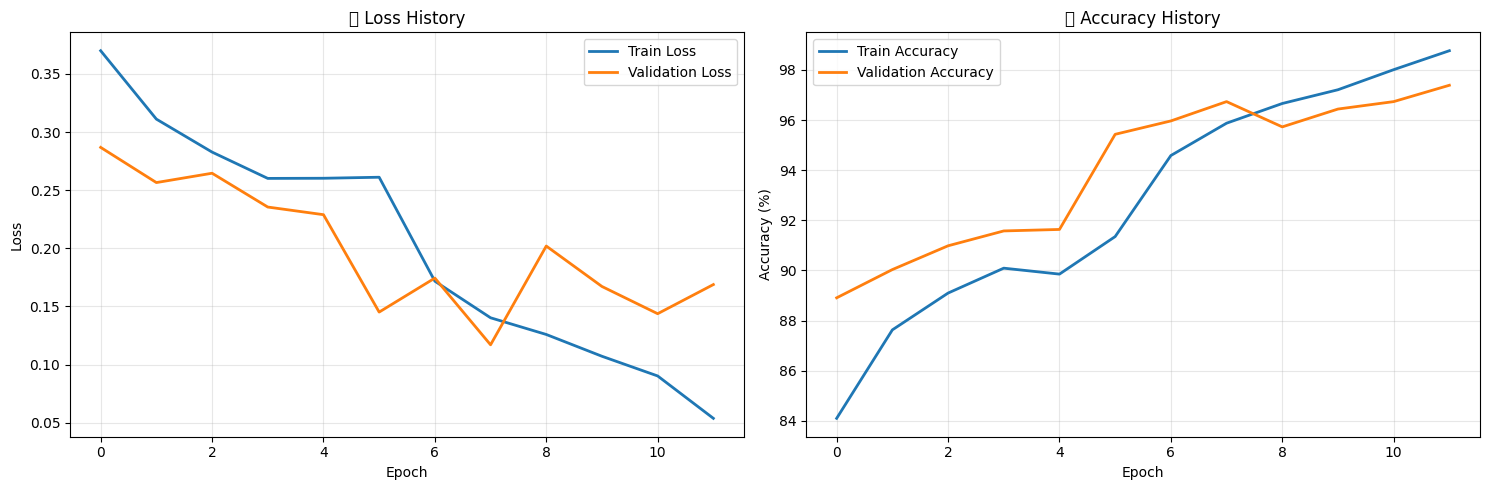


🧪 Starting final evaluation...



🎯 Final Test Results:
📉 Test Loss: 0.1046
📈 Test Accuracy: 97.96%
🎯 Precision: 0.9865
🔍 Recall: 0.9693
⭐ F1 Score: 0.9778

📊 Confusion Matrix:


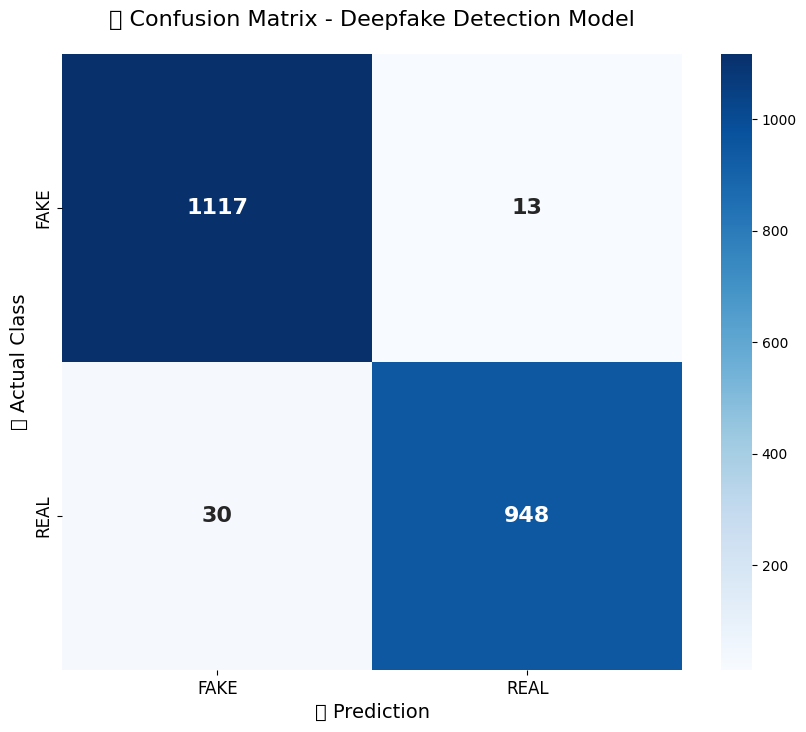


📈 Detailed Analysis:
✅ True Negative (Correct FAKE predictions): 1117
❌ False Positive (FAKE predicted as REAL): 13
❌ False Negative (REAL predicted as FAKE): 30
✅ True Positive (Correct REAL predictions): 948

📊 Error Rates:
📈 False Positive Rate: 0.0115
📉 False Negative Rate: 0.0307

📋 Detailed Classification Report:
              precision    recall  f1-score   support

        FAKE     0.9738    0.9885    0.9811      1130
        REAL     0.9865    0.9693    0.9778       978

    accuracy                         0.9796      2108
   macro avg     0.9802    0.9789    0.9795      2108
weighted avg     0.9797    0.9796    0.9796      2108



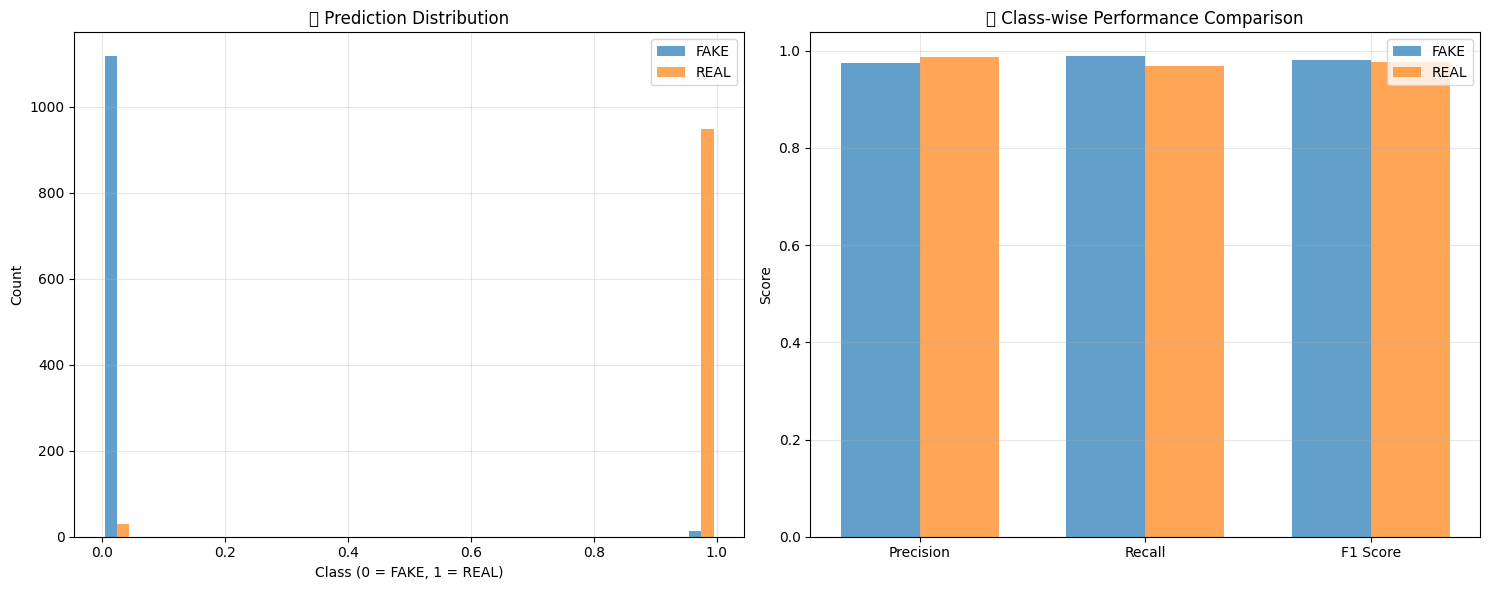


🎯 Overall Performance Analysis:
📊 Overall Accuracy: 0.9796
⚖️ Balanced Accuracy: 0.9789
✅ Model is balanced and performs well across both classes

🎊 Evaluation Completed Successfully!


In [16]:
# -------------------------
# Model Evaluation & Visualization After Successful Loading
# -------------------------

def evaluate(model, test_loader, criterion, device):
    """Improved Evaluation Function"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, targets in tqdm(test_loader, desc="🔄 Evaluating", leave=False):
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=config["use_amp"]):
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            running_loss += loss.item() * targets.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

            # Save predictions and labels
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())

    avg_loss = running_loss / (total + 1e-12)
    acc = 100.0 * correct / (total + 1e-12)
    return avg_loss, acc, all_preds, all_labels


def plot_training_history(history):
    """Training History Plot"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss Plot
    ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
    ax1.plot(history['val_loss'], label='Validation Loss', linewidth=2)
    ax1.set_title('📉 Loss History')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy Plot
    ax2.plot(history['train_acc'], label='Train Accuracy', linewidth=2)
    ax2.plot(history['val_acc'], label='Validation Accuracy', linewidth=2)
    ax2.set_title('📈 Accuracy History')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Load Model
print("🔄 Loading trained model...")

try:
    ck = torch.load(checkpoint_path, map_location=device)

    # Load weights
    model.load_state_dict(ck['model_state'])
    model.to(device)
    model.eval()

    print("✅ Model loaded successfully!")

    # Show model info
    if 'epoch' in ck:
        print(f"📅 Model from epoch: {ck['epoch'] + 1}")
    if 'val_acc' in ck:
        print(f"🎯 Validation Accuracy: {ck['val_acc']:.2f}%")
    if 'history' in ck:
        print("📊 Plotting training history...")
        plot_training_history(ck['history'])

except Exception as e:
    print(f"❌ Error loading model: {e}")

    # Search for fallback
    import glob
    checkpoints = glob.glob('/content/checkpoints/*.pth')
    if checkpoints:
        checkpoint_path = checkpoints[0]
        print(f"🔄 Using fallback model: {checkpoint_path}")
        ck = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ck['model_state'])
        model.to(device)
        model.eval()
    else:
        raise FileNotFoundError("❌ No saved models found")


# Final Evaluation
print("\n🧪 Starting final evaluation...")
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print(f'\n🎯 Final Test Results:')
print(f'📉 Test Loss: {test_loss:.4f}')
print(f'📈 Test Accuracy: {test_acc:.2f}%')


# Additional Metrics
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

precision, recall, f1, _ = precision_recall_fscore_support(test_labels, test_preds, average='binary')
print(f'🎯 Precision: {precision:.4f}')
print(f'🔍 Recall: {recall:.4f}')
print(f'⭐ F1 Score: {f1:.4f}')


# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

print("\n📊 Confusion Matrix:")
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE', 'REAL'],
            yticklabels=['FAKE', 'REAL'],
            annot_kws={"size": 16, "weight": "bold"})

plt.title('📋 Confusion Matrix - Deepfake Detection Model', fontsize=16, pad=20)
plt.ylabel('🏷️ Actual Class', fontsize=14)
plt.xlabel('🔮 Prediction', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Detailed Confusion Matrix Analysis
tn, fp, fn, tp = cm.ravel()
print(f"\n📈 Detailed Analysis:")
print(f"✅ True Negative (Correct FAKE predictions): {tn}")
print(f"❌ False Positive (FAKE predicted as REAL): {fp}")
print(f"❌ False Negative (REAL predicted as FAKE): {fn}")
print(f"✅ True Positive (Correct REAL predictions): {tp}")

# Error Rates
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f"\n📊 Error Rates:")
print(f"📈 False Positive Rate: {false_positive_rate:.4f}")
print(f"📉 False Negative Rate: {false_negative_rate:.4f}")

# Classification Report
print("\n📋 Detailed Classification Report:")
print(classification_report(test_labels, test_preds,
                          target_names=['FAKE', 'REAL'],
                          digits=4))

# Performance Per Class
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Convert lists to numpy
test_preds_np = np.array(test_preds)
test_labels_np = np.array(test_labels)

# Prediction Distribution
fake_preds = test_preds_np[test_labels_np == 0]
real_preds = test_preds_np[test_labels_np == 1]

ax1.hist([fake_preds, real_preds],
         label=['FAKE', 'REAL'], alpha=0.7, bins=20)
ax1.set_title('📊 Prediction Distribution')
ax1.set_xlabel('Class (0 = FAKE, 1 = REAL)')
ax1.set_ylabel('Count')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Class-wise Comparison
categories = ['Precision', 'Recall', 'F1 Score']
fake_scores = [precision_score(test_labels, test_preds, pos_label=0),
               recall_score(test_labels, test_preds, pos_label=0),
               f1_score(test_labels, test_preds, pos_label=0)]
real_scores = [precision_score(test_labels, test_preds, pos_label=1),
               recall_score(test_labels, test_preds, pos_label=1),
               f1_score(test_labels, test_preds, pos_label=1)]

x = np.arange(len(categories))
width = 0.35

ax2.bar(x - width/2, fake_scores, width, label='FAKE', alpha=0.7)
ax2.bar(x + width/2, real_scores, width, label='REAL', alpha=0.7)

ax2.set_title('📈 Class-wise Performance Comparison')
ax2.set_ylabel('Score')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Overall Performance
print("\n🎯 Overall Performance Analysis:")
overall_accuracy = accuracy_score(test_labels, test_preds)
balanced_accuracy = balanced_accuracy_score(test_labels, test_preds)

print(f"📊 Overall Accuracy: {overall_accuracy:.4f}")
print(f"⚖️ Balanced Accuracy: {balanced_accuracy:.4f}")

if balanced_accuracy > 0.75:
    print("✅ Model is balanced and performs well across both classes")
elif balanced_accuracy > 0.6:
    print("⚠️ Model needs improvement in class balance")
else:
    print("❌ Model is unbalanced and needs retraining")

print(f"\n🎊 Evaluation Completed Successfully!")


🚀 Starting data and image extraction...
💾 Saving the model and weights...
📊 Saving plots...
🖼️ Saving image samples...
⚠️ Error saving image samples: Invalid shape (10, 3, 112, 112) for image data
📈 Saving results and statistics...
🗜️ Creating ZIP archive...
✅ Completed! ZIP file created: model_export_20251123_081910.zip
🎉 ZIP file successfully created: model_export_20251123_081910.zip
📦 File size: 78.11 MB


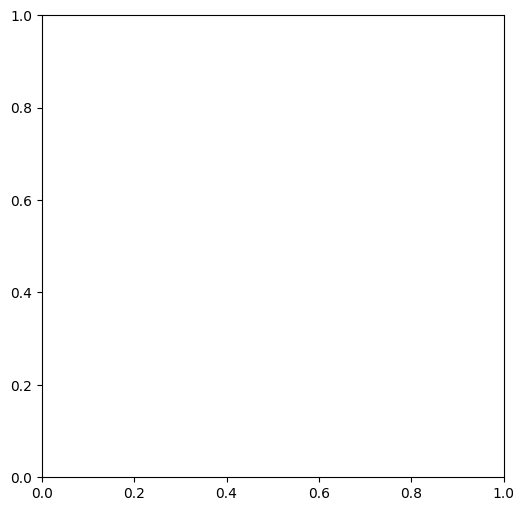

In [17]:
import os
import zipfile
import shutil
import numpy as np
from PIL import Image
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import json
from datetime import datetime

def create_comprehensive_export(model, test_loader, test_preds, test_labels,
                              history, config, export_dir="model_export"):
    """
    Create a comprehensive export of the model, data, and results
    """
    print("🚀 Starting data and image extraction...")

    # Create the main folder
    if not os.path.exists(export_dir):
        os.makedirs(export_dir)

    # Create subfolders
    folders = ['images', 'model', 'results', 'data_samples']
    for folder in folders:
        folder_path = os.path.join(export_dir, folder)
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)

    # 1. Save model and weights
    print("💾 Saving the model and weights...")
    model_path = os.path.join(export_dir, 'model')
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': config,
        'history': history
    }, os.path.join(model_path, 'trained_model.pth'))

    # Save model architecture
    with open(os.path.join(model_path, 'model_architecture.txt'), 'w', encoding='utf-8') as f:
        f.write(str(model))

    # 2. Save plots
    print("📊 Saving plots...")
    save_plots(export_dir, history, test_preds, test_labels)

    # 3. Save sample data
    print("🖼️ Saving image samples...")
    save_data_samples(test_loader, export_dir, test_preds, test_labels)

    # 4. Save results and statistics
    print("📈 Saving results and statistics...")
    save_results(export_dir, test_preds, test_labels, history, config)

    # 5. Create README file
    create_readme(export_dir, config, test_preds, test_labels)

    # 6. Create ZIP file
    print("🗜️ Creating ZIP archive...")
    zip_path = create_zip_file(export_dir)

    print(f"✅ Completed! ZIP file created: {zip_path}")
    return zip_path


def save_plots(export_dir, history, test_preds, test_labels):
    """Save all generated plots"""
    images_dir = os.path.join(export_dir, 'images')

    # 1. Training history plot
    if history and 'train_loss' in history and 'val_loss' in history:
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
        plt.plot(history['val_loss'], label='Validation Loss', linewidth=2)
        plt.title('📉 Training Loss History')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.plot(history['train_acc'], label='Train Accuracy', linewidth=2)
        plt.plot(history['val_acc'], label='Validation Accuracy', linewidth=2)
        plt.title('📈 Training Accuracy History')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(os.path.join(images_dir, 'training_history.png'), dpi=300, bbox_inches='tight')
        plt.close()

    # 2. Confusion matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(test_labels, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['FAKE', 'REAL'],
                yticklabels=['FAKE', 'REAL'],
                annot_kws={"size": 16, "weight": "bold"})
    plt.title('📋 Confusion Matrix', fontsize=16, pad=20)
    plt.ylabel('🏷️ True Label', fontsize=14)
    plt.xlabel('🔮 Prediction', fontsize=14)
    plt.savefig(os.path.join(images_dir, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
    plt.close()

    # 3. Prediction distribution and performance comparison
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    test_preds_np = np.array(test_preds)
    test_labels_np = np.array(test_labels)

    fake_preds = test_preds_np[test_labels_np == 0]
    real_preds = test_preds_np[test_labels_np == 1]

    plt.hist([fake_preds, real_preds], label=['FAKE', 'REAL'], alpha=0.7, bins=20)
    plt.title('📊 Prediction Distribution')
    plt.xlabel('Class (0 = FAKE, 1 = REAL)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    categories = ['Precision', 'Recall', 'F1 Score']
    fake_scores = [
        precision_score(test_labels, test_preds, pos_label=0),
        recall_score(test_labels, test_preds, pos_label=0),
        f1_score(test_labels, test_preds, pos_label=0)
    ]
    real_scores = [
        precision_score(test_labels, test_preds, pos_label=1),
        recall_score(test_labels, test_preds, pos_label=1),
        f1_score(test_labels, test_preds, pos_label=1)
    ]

    x = np.arange(len(categories))
    width = 0.35

    plt.bar(x - width/2, fake_scores, width, label='FAKE', alpha=0.7)
    plt.bar(x + width/2, real_scores, width, label='REAL', alpha=0.7)

    plt.title('📈 Performance Comparison')
    plt.ylabel('Score')
    plt.xticks(x, categories)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, 'performance_analysis.png'), dpi=300, bbox_inches='tight')
    plt.close()


def save_data_samples(test_loader, export_dir, test_preds, test_labels):
    """Save sample images with predictions"""
    samples_dir = os.path.join(export_dir, 'data_samples')

    try:
        data_iter = iter(test_loader)
        images, labels = next(data_iter)

        for i in range(min(20, len(images))):
            plt.figure(figsize=(6, 6))

            img = images[i].cpu().numpy()

            if img.ndim == 3:
                if img.shape[0] == 1:
                    img = img[0]
                elif img.shape[0] == 3:
                    img = img.transpose(1, 2, 0)

            if img.min() < 0:
                img = (img - img.min()) / (img.max() - img.min())
            elif img.max() > 1:
                img = img / 255.0

            true_label = "REAL" if labels[i].item() == 1 else "FAKE"
            pred_label = "REAL" if test_preds[i] == 1 else "FAKE"
            correct = "✅" if true_label == pred_label else "❌"

            if img.ndim == 2:
                plt.imshow(img, cmap='gray')
            else:
                plt.imshow(img)

            plt.title(f'{correct} True: {true_label} | Predicted: {pred_label}', fontsize=12)
            plt.axis('off')

            plt.savefig(os.path.join(samples_dir, f'sample_{i+1}.png'),
                       dpi=150, bbox_inches='tight')
            plt.close()

    except Exception as e:
        print(f"⚠️ Error saving image samples: {e}")
        plt.figure(figsize=(6, 6))
        plt.text(0.5, 0.5, f"Error loading image\n{str(e)}",
                 ha='center', va='center', fontsize=12)
        plt.axis('off')
        plt.savefig(os.path.join(samples_dir, 'error_sample.png'),
                   dpi=150, bbox_inches='tight')
        plt.close()


def save_results(export_dir, test_preds, test_labels, history, config):
    """Save detailed evaluation results"""
    results_dir = os.path.join(export_dir, 'results')

    accuracy = accuracy_score(test_labels, test_preds)
    precision = precision_score(test_labels, test_preds, average='binary')
    recall = recall_score(test_labels, test_preds, average='binary')
    f1 = f1_score(test_labels, test_preds, average='binary')

    cm = confusion_matrix(test_labels, test_preds)
    tn, fp, fn, tp = cm.ravel()

    with open(os.path.join(results_dir, 'statistics.txt'), 'w', encoding='utf-8') as f:
        f.write("📊 Detailed Results for Deepfake Detection Model\n")
        f.write("=" * 50 + "\n\n")

        f.write("🎯 Overall Statistics:\n")
        f.write(f"   Accuracy: {accuracy:.4f}\n")
        f.write(f"   Precision: {precision:.4f}\n")
        f.write(f"   Recall: {recall:.4f}\n")
        f.write(f"   F1 Score: {f1:.4f}\n\n")

        f.write("📈 Confusion Matrix Analysis:\n")
        f.write(f"   True Negative (TN): {tn}\n")
        f.write(f"   False Positive (FP): {fp}\n")
        f.write(f"   False Negative (FN): {fn}\n")
        f.write(f"   True Positive (TP): {tp}\n\n")

        f.write(f"   False Alarm Rate: {fp/(fp+tn):.4f}\n")
        f.write(f"   Miss Rate: {fn/(fn+tp):.4f}\n\n")

        if history and 'train_acc' in history:
            f.write("🔄 Training History:\n")
            f.write(f"   Best Train Accuracy: {max(history['train_acc']):.2f}%\n")
            f.write(f"   Best Validation Accuracy: {max(history['val_acc']):.2f}%\n")
            f.write(f"   Total Epochs: {len(history['train_acc'])}\n\n")

        f.write("⚙️ Model Configuration:\n")
        for key, value in config.items():
            f.write(f"   {key}: {value}\n")

    report = classification_report(test_labels, test_preds,
                                   target_names=['FAKE', 'REAL'],
                                   digits=4)
    with open(os.path.join(results_dir, 'classification_report.txt'), 'w', encoding='utf-8') as f:
        f.write("📋 Classification Report:\n")
        f.write("=" * 40 + "\n\n")
        f.write(report)

    results_data = {
        'timestamp': datetime.now().isoformat(),
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'confusion_matrix': cm.tolist(),
        'config': config
    }

    if history and 'train_acc' in history:
        results_data['best_train_accuracy'] = float(max(history['train_acc']))
        results_data['best_val_accuracy'] = float(max(history['val_acc']))

    with open(os.path.join(results_dir, 'results.json'), 'w', encoding='utf-8') as f:
        json.dump(results_data, f, indent=2, ensure_ascii=False)


def create_readme(export_dir, config, test_preds, test_labels):
    """Create README file for explanation"""
    readme_path = os.path.join(export_dir, 'README.md')

    accuracy = accuracy_score(test_labels, test_preds)

    with open(readme_path, 'w', encoding='utf-8') as f:
        f.write("# 📊 Deepfake Detection Model Export\n\n")
        f.write("## 📁 Folder Structure\n")
        f.write("""
- `/images/` - Contains all generated plots
- `/model/` - Contains the trained model and architecture
- `/results/` - Contains detailed evaluation results
- `/data_samples/` - Contains sample frames with predictions

## 📈 Model Performance\n""")
        f.write(f"- **Overall Accuracy**: {accuracy:.2%}\n")
        f.write(f"- **Total Samples**: {len(test_preds)}\n")
        f.write(f"- **Creation Date**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

        f.write("## 🚀 How to Use\n")
        f.write("""
1. Extract the ZIP file
2. Open `/images/` to view plots
3. See `/results/` for detailed metrics
4. Load the model from `model/trained_model.pth`

## 🔧 Used Configuration\n""")

        for key, value in config.items():
            f.write(f"- **{key}**: `{value}`\n")


def create_zip_file(export_dir):
    """Create a ZIP file from the export directory"""
    zip_filename = f"model_export_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"

    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(export_dir):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(export_dir))
                zipf.write(file_path, arcname)

    shutil.rmtree(export_dir)

    return zip_filename


# Run with error handling
try:
    zip_file_path = create_comprehensive_export(
        model=model,
        test_loader=test_loader,
        test_preds=test_preds,
        test_labels=test_labels,
        history=ck.get('history', {}),
        config=config
    )

    print(f"🎉 ZIP file successfully created: {zip_file_path}")
    if os.path.exists(zip_file_path):
        print(f"📦 File size: {os.path.getsize(zip_file_path) / (1024*1024):.2f} MB")

except Exception as e:
    print(f"❌ Error during export: {e}")
    print("🔄 Trying the quick export version...")

    quick_export(model, test_preds, test_labels, test_acc/100)
